In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/banks_with_ratios.csv")
df["bank_name"] = df["bank_name"].str.replace('"', '').str.strip()
print(df.groupby("year")["bank_name"].count())

year
2023    21
2024    21
2025    21
2026    23
Name: bank_name, dtype: int64


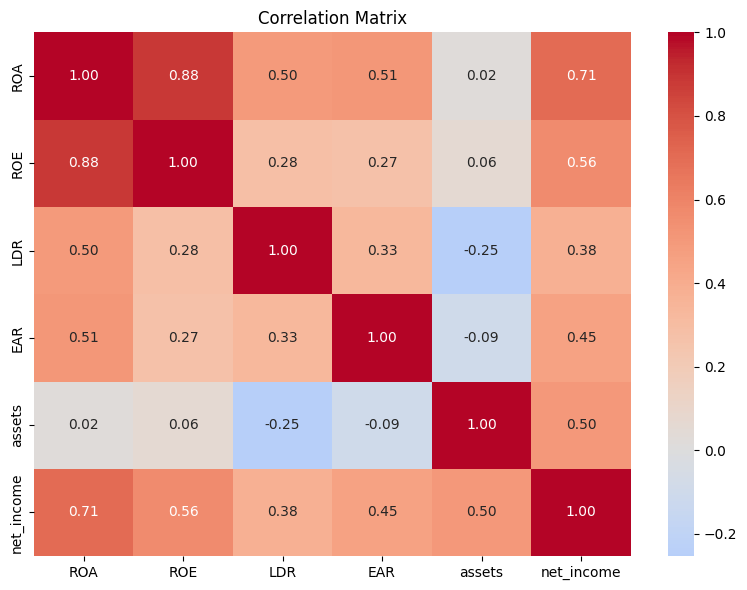

In [2]:
df_corr = df[df["LDR"] < 10].copy()
df_corr = df_corr[df_corr["ROE"] < 10]

metrics = ["ROA", "ROE", "LDR", "EAR", "assets", "net_income"]
corr = df_corr[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

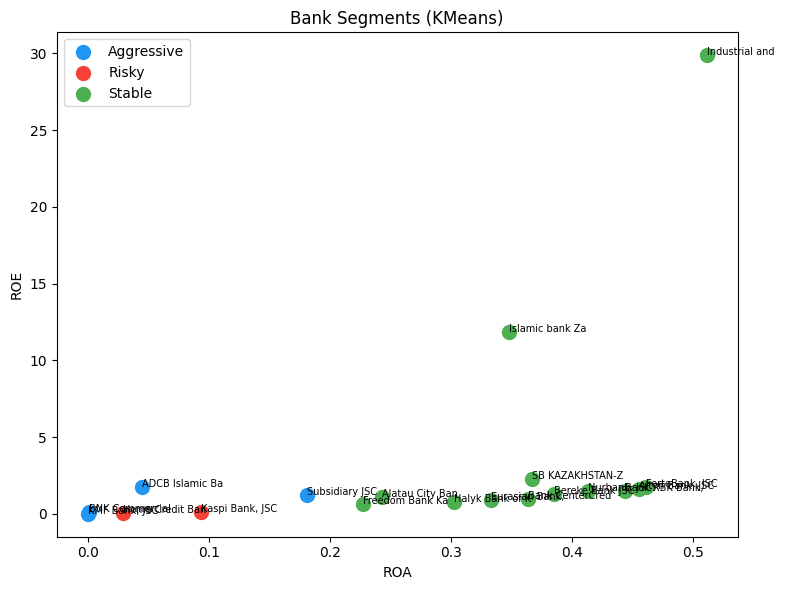

In [3]:
df_cluster = df[df["year"] == 2026][["bank_name", "ROA", "ROE", "LDR", "EAR", "assets"]].dropna()
df_cluster = df_cluster[df_cluster["ROE"] < 100]
df_cluster = df_cluster[df_cluster["LDR"] < 100]

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[["ROA", "ROE", "LDR", "EAR"]])

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X)

labels = {0: "Stable", 1: "Aggressive", 2: "Risky"}
df_cluster["segment"] = df_cluster["cluster"].map(labels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Stable": "#4CAF50", "Aggressive": "#2196F3", "Risky": "#f44336"}
for segment, group in df_cluster.groupby("segment"):
    ax.scatter(group["ROA"], group["ROE"], label=segment, color=colors[segment], s=100)
    for _, row in group.iterrows():
        ax.annotate(row["bank_name"][:15], (row["ROA"], row["ROE"]), fontsize=7)

ax.set_xlabel("ROA")
ax.set_ylabel("ROE")
ax.set_title("Bank Segments (KMeans)")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
print(df[df["year"] == 2026][["bank_name", "ROA", "ROE", "LDR"]].to_string())

                                                       bank_name           ROA         ROE          LDR
63                                 Halyk Bank of Kazakhstan, JSC  3.028330e-01    0.790197    22.580987
64                                               Kaspi Bank, JSC  9.352161e-02    0.125870    22.135510
65                                        Bank CenterCredit, JSC  3.638046e-01    0.935609    22.457736
66                                              Otbasy bank, JSC  1.712023e-02    0.028583   382.830913
67                                                ForteBank, JSC  4.613145e-01    1.751619    26.014816
68                                         Alatau City Bank, JSC  2.432818e-01    1.083713    14.957204
69                                            Eurasian Bank, JSC  3.333035e-01    0.902846    12.502229
70               Bereke Bank JSC (SB of Lesha Bank LLC (Public))  3.854267e-01    1.271985     9.886433
71                                            Bank RBK Bank, JSC

(31, 8)


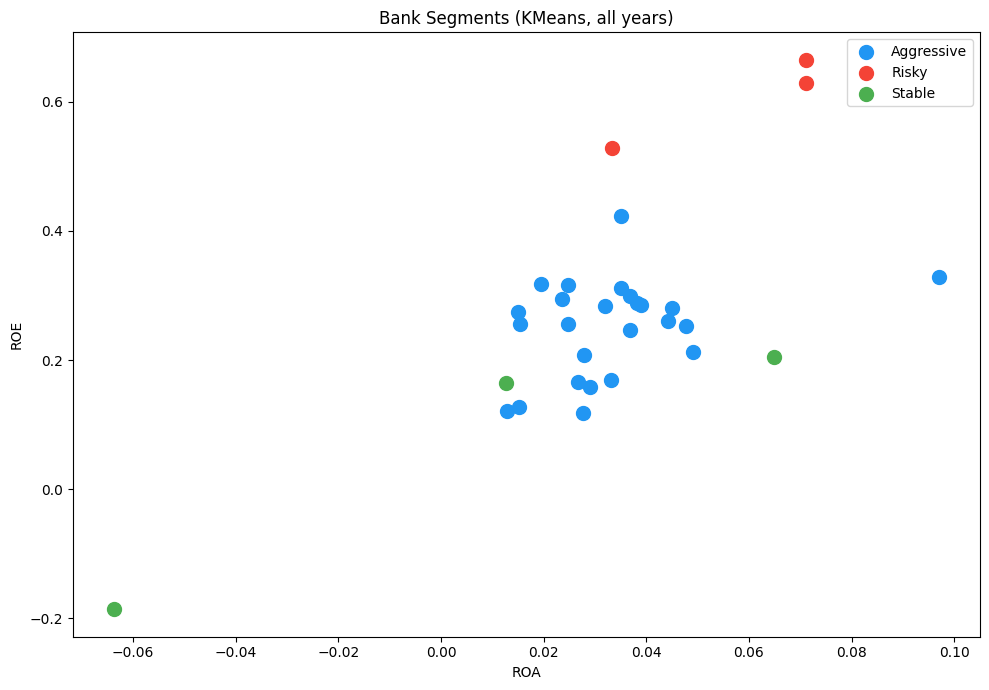

In [5]:
df_cluster = df[["bank_name", "year", "ROA", "ROE", "LDR", "EAR"]].dropna()
df_cluster = df_cluster[df_cluster["ROA"] < 0.15]
df_cluster = df_cluster[df_cluster["ROE"] < 1.0]
df_cluster = df_cluster[df_cluster["LDR"] < 5]

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[["ROA", "ROE", "LDR", "EAR"]])

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X)

labels = {0: "Stable", 1: "Aggressive", 2: "Risky"}
df_cluster["segment"] = df_cluster["cluster"].map(labels)

print(df_cluster.shape)
fig, ax = plt.subplots(figsize=(10, 7))
colors = {"Stable": "#4CAF50", "Aggressive": "#2196F3", "Risky": "#f44336"}
for segment, group in df_cluster.groupby("segment"):
    ax.scatter(group["ROA"], group["ROE"], label=segment, color=colors[segment], s=100)

ax.set_xlabel("ROA")
ax.set_ylabel("ROE")
ax.set_title("Bank Segments (KMeans, all years)")
ax.legend()
plt.tight_layout()
plt.show()

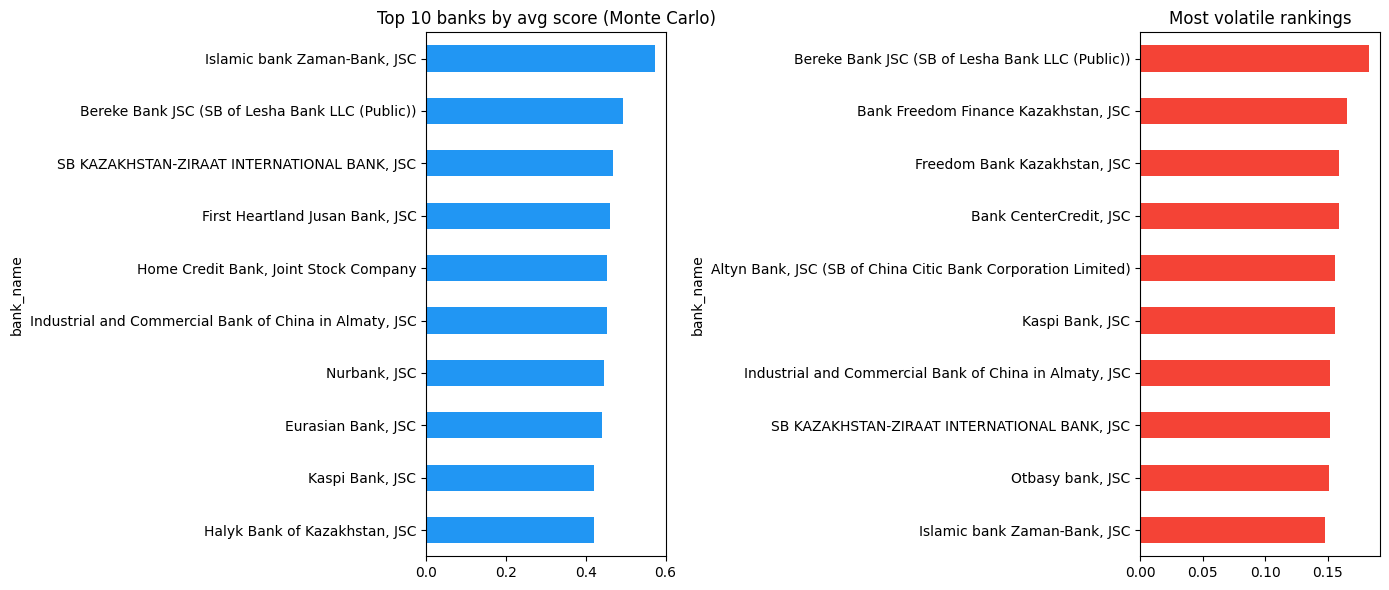

In [6]:


base_weights = {"roa": 0.35, "roe": 0.35, "ldr": 0.15, "ear": 0.15}

def score_with_weights(df, w):
    from sklearn.preprocessing import MinMaxScaler
    d = df[df["LDR"] < 10].copy()
    scaler = MinMaxScaler()
    d["ROA_n"] = scaler.fit_transform(d[["ROA"]])
    d["ROE_n"] = scaler.fit_transform(d[["ROE"]])
    d["EAR_n"] = scaler.fit_transform(d[["EAR"]])
    d["LDR_s"] = 1 - abs(d["LDR"] - 1) / d["LDR"].max()
    d["score"] = d["ROA_n"]*w["roa"] + d["ROE_n"]*w["roe"] + d["LDR_s"]*w["ldr"] + d["EAR_n"]*w["ear"]
    return d.groupby("bank_name")["score"].mean()

np.random.seed(42)
results = []
for _ in range(500):
    w = np.random.dirichlet([1, 1, 1, 1])
    weights = {"roa": w[0], "roe": w[1], "ldr": w[2], "ear": w[3]}
    scores = score_with_weights(df, weights)
    results.append(scores)

mc = pd.DataFrame(results)
mean_score = mc.mean().sort_values(ascending=False)
std_score = mc.std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mean_score.head(10).plot(kind="barh", ax=axes[0], color="#2196F3")
axes[0].set_title("Top 10 banks by avg score (Monte Carlo)")
axes[0].invert_yaxis()

std_score.head(10).plot(kind="barh", ax=axes[1], color="#f44336")
axes[1].set_title("Most volatile rankings")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

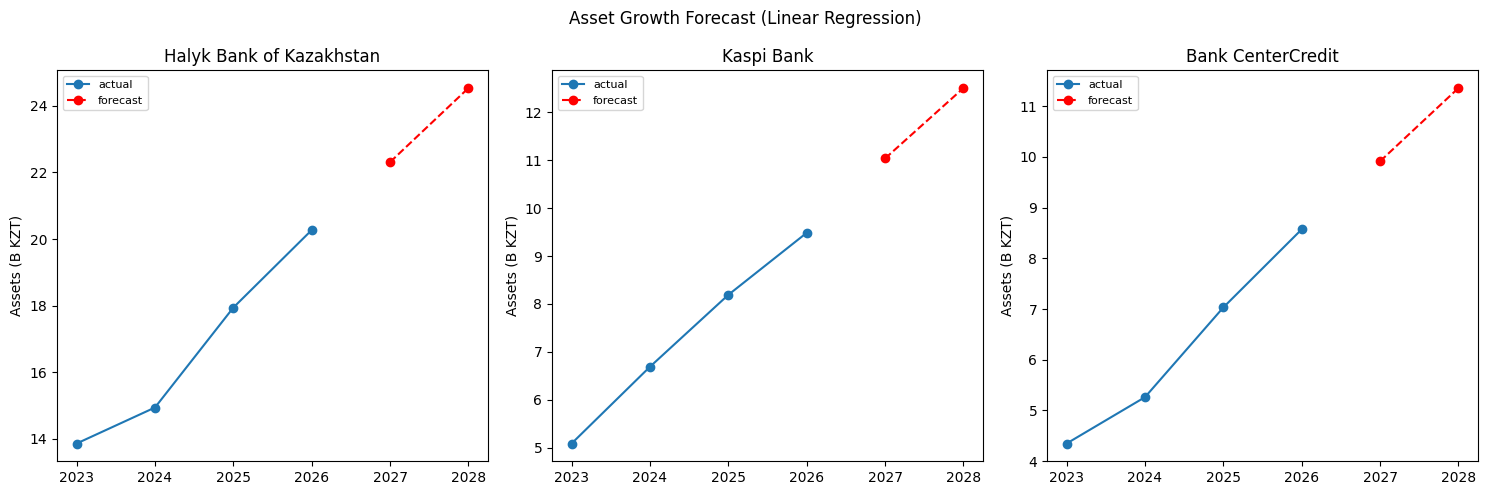

In [7]:
from sklearn.linear_model import LinearRegression

banks_to_forecast = ["Halyk Bank of Kazakhstan, JSC", "Kaspi Bank, JSC", "Bank CenterCredit, JSC"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, bank in enumerate(banks_to_forecast):
    d = df[df["bank_name"].str.contains(bank.split(",")[0])].sort_values("year")
    
    X = d["year"].values.reshape(-1, 1)
    y = d["assets"].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    future_years = np.array([2027, 2028]).reshape(-1, 1)
    forecast = model.predict(future_years)
    
    axes[i].plot(d["year"], d["assets"]/1e9, marker="o", label="actual")
    axes[i].plot([2027, 2028], forecast/1e9, marker="o", linestyle="--", color="red", label="forecast")
    axes[i].set_title(bank.split(",")[0])
    axes[i].set_ylabel("Assets (B KZT)")
    axes[i].legend(fontsize=8)

plt.suptitle("Asset Growth Forecast (Linear Regression)")
plt.tight_layout()
plt.show()